In [1]:
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset, Subset
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
import pickle
import os
from PIL import Image
from matplotlib.pyplot import GridSpec
import snntorch as snn
from snntorch import spikegen
from snntorch import surrogate
from snntorch import spikeplot

In [2]:
DATA_DIR = "../data"
DATASET_DIR = f"{DATA_DIR}/processed"

In [3]:
# data = pd.read_parquet(f"{DATASET_DIR}/csecicids2018.parquet")

In [4]:
# label_mapping = {
#     'Benign': 'Benign',
#     'Bot': 'Botnet',
#     'FTP-BruteForce': 'Brute Force',
#     'SSH-Bruteforce': 'Brute Force',
#     'DDoS attacks-LOIC-HTTP': 'DDoS',
#     'DDOS attack-LOIC-UDP': 'DDoS',
#     'DDOS attack-HOIC': 'DDoS',
#     'DoS attacks-GoldenEye': 'DoS',
#     'DoS attacks-Slowloris': 'DoS',
#     'DoS attacks-SlowHTTPTest': 'DoS',
#     'DoS attacks-Hulk': 'DoS',
#     'Infilteration': 'Infiltration',
#     'Brute Force -Web': 'Brute Force',
#     'Brute Force -XSS': 'Brute Force',
#     'SQL Injection': 'Infiltration'  # Assuming SQL Injection is part of Infiltration
# }

# data["Label"] = data["Label"].map(label_mapping)

In [5]:
from sklearn.preprocessing import LabelEncoder

class CustomDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.dataframe = dataframe
        self.image_dir = image_dir
        self.transform = transform
    
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        image_path = os.path.join(self.image_dir, self.dataframe.iloc[idx]["Image"])
        with Image.open(image_path) as img:
            if self.transform:
                img = self.transform(img)
            label = torch.as_tensor(self.dataframe.iloc[idx]["Label"], dtype=torch.long)
            return img, label

In [6]:
train_df = pd.read_csv(f"{DATASET_DIR}/train_multi.csv")
test_df = pd.read_csv(f"{DATASET_DIR}/test_multi.csv")
val_df = pd.read_csv(f"{DATASET_DIR}/val_multi.csv")

In [7]:
LE = LabelEncoder()
LE.fit(train_df["Label"].unique())

# LE.classes_

# swap classes in the label encoder
# swapped_classes = LE.classes_.copy()
# swapped_classes[0], swapped_classes[1] = swapped_classes[1], swapped_classes[0]

# LE.classes_ = swapped_classes

train_df_encoded = train_df.copy()
train_df_encoded["Label"] = LE.transform(train_df_encoded["Label"])

val_df_encoded = val_df.copy()
val_df_encoded["Label"] = LE.transform(val_df_encoded["Label"])

train_df_encoded.head()

,Image,Label
0,image_1119705.png,0
1,image_2975672.png,0
2,image_6489183.png,0
3,image_2675390.png,0
4,image_5559062.png,0


In [ ]:
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize((0,), (1,))  # normalize to mean 0, std 1
])

# Keep validation transforms simple - just basic preprocessing
val_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize((0,), (1,))  # normalize to mean 0, std 1
])

train_dataset = CustomDataset(train_df_encoded, f"{DATASET_DIR}/images", transform=train_transform)
val_dataset = CustomDataset(val_df_encoded, f"{DATASET_DIR}/images", transform=val_transform)

In [9]:
from torch.utils.data import WeightedRandomSampler
from sklearn.utils.class_weight import compute_class_weight

labels = train_df_encoded["Label"].values
class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(labels), y=labels)
sample_weights = class_weights[labels]

sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

In [10]:
BATCH_SIZE = 40
train_data_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)
val_data_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [1]:
class SNNClassifier(nn.Module):
    def __init__(self, num_classes=2, time_steps=4, threshold=0.3, alpha=0.3, grad_clip=1.0):
        super().__init__()
        self.time_steps = time_steps
        
        # First Conv-Spiking Layer: (1, 32, 32) → (16, 8, 8)
        self.conv1 = ConvSpikingLayer(1, 16, kernel_size=4, stride=4, 
                                     threshold=threshold, alpha=alpha)
        
        # Second Conv-Spiking Layer: (16, 8, 8) → (32, 4, 4)
        self.conv2 = ConvSpikingLayer(16, 32, kernel_size=2, stride=2,
                                     threshold=threshold, alpha=alpha)
        
        # Time-value encoder
        self.encoder = TimeValEncoder(time_steps)
        
        # Linear classifier
        self.fc = nn.Linear(32 * 4 * 4, num_classes)
        
        # Gradient clipping parameters
        self.grad_clip = grad_clip

        # Placeholder for spiking activations
        self.spk1 = None
        self.spk2 = None

    def forward(self, x):
        # Add time dimension: (B,C,H,W) → (B,C,H,W,T)
        x = x.unsqueeze(-1).repeat(1,1,1,1,self.time_steps)
        
        # Temporal processing
        spk1, _ = self.conv1(x)
        spk2, _ = self.conv2(spk1)

        self.spk1 = spk1
        self.spk2 = spk2
        
        # Time-value encoding
        encoded = self.encoder(spk2)
        
        # Classification
        out = self.fc(encoded.flatten(1))

        return torch.softmax(out, dim=1)

class ConvSpikingLayer(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride, 
                 threshold=0.3, alpha=0.3):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, 
                             stride, padding='valid')
        
        self.lif = snn.Leaky(
            beta=1.0,  # No leakage (V(t) = V(t-1) + I(t-1))
            threshold=threshold,
            reset_mechanism="subtract",
            spike_grad=surrogate.fast_sigmoid(slope=25),
            output=True
        )
        self.alpha = alpha

    def forward(self, x):
        # x shape: (B,C,H,W,T)
        batch_size, _, h, w, _ = x.shape
        
        # Initialize membrane potential
        mem = self.lif.init_leaky()
        
        spk_rec = []
        mem_rec = []
        for t in range(x.size(-1)):
            conv_out = self.conv(x[..., t])
            spk, mem = self.lif(conv_out, mem)
            
            # Document-specific reset: (V - V_thr) * α
            mem = (mem - self.lif.threshold) * self.alpha * (spk > 0).float() \
                + mem * (spk <= 0).float()
            
            spk_rec.append(spk)
            mem_rec.append(mem)
            
        return torch.stack(spk_rec, dim=0), torch.stack(mem_rec, dim=0)

class TimeValEncoder(nn.Module):
    def __init__(self, time_steps):
        super().__init__()
        weights = [2**(time_steps-i-1) for i in range(time_steps)]
        weights = torch.tensor(weights, dtype=torch.float32)
        self.weights = nn.Parameter(weights/weights.sum(), requires_grad=False)

    def forward(self, x):
        # x: (B,C,H,W,T)
        return torch.einsum('b...t,t->b...', x, self.weights.to(x.device))

class CustomLoss(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.n_classes = n_classes

    def forward(self, predict, target):
        target_onehot = torch.zeros_like(predict).scatter(1, target.unsqueeze(1), 1)
        
        # Max correlation between prediction and target
        cor = (predict * target_onehot).sum(1)
        
        # Max prediction values
        pre = predict.max(1)[0]
        
        # Ranking of correct class
        idx = target_onehot.argmax(1)
        val = predict.gather(1, idx.unsqueeze(1)).squeeze()
        ids = (predict > val.unsqueeze(1)).sum(1)
        
        # Loss components
        alpha = pre - cor
        beta = 1 - cor
        
        return (self.n_classes * alpha + (ids + 1) * beta).mean()
    
class CustomLoss2(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.n_classes = n_classes

    def forward(self, predict, target):
        target_onehot = torch.zeros_like(predict).scatter(1, target.unsqueeze(1), 1)
        
        # Value of correct class (cor)
        cor = predict.gather(1, target.unsqueeze(1)).squeeze()
        
        # Max prediction EXCLUDING correct class (pre)
        pre = (predict - target_onehot * 1e9).max(1)[0]  # Mask correct class
        
        # Ranking of correct class (ids)
        ids = (predict > cor.unsqueeze(1)).sum(1)
        
        # Loss components (Algorithm 2)
        alpha = torch.relu(pre - cor)  # Ensures non-negativity
        beta = 1 - cor
        
        return (self.n_classes * alpha + (ids + 1) * beta).mean()

# --- Training Utilities ---
def gradient_clip_hook(module, grad_input, grad_output):
    """Clips gradients to ±module.grad_clip, skipping None gradients."""
    clipped_grads = []
    for g in grad_input:
        if g is not None:
            clipped_grads.append(torch.clamp(g, -module.grad_clip, module.grad_clip))
        else:
            clipped_grads.append(g)  # Preserve None values
    return tuple(clipped_grads)

def create_optimizer(model, lr=0.001, T_max=50, weight_decay=0.0, betas=(0.9, 0.999)):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay, betas=betas)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=T_max, eta_min=0
    )
    
    # Add grad_clip to all trainable layers
    for module in model.modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            module.grad_clip = model.grad_clip
    
    # Register hooks
    for module in model.modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            module.register_full_backward_hook(gradient_clip_hook)
    
    return optimizer, scheduler
    

NameError: name 'nn' is not defined

In [12]:
# dummy = torch.randn(40, 1, 32, 32)
# model = SNNClassifier(num_classes=4, time_steps=4)
# outputs = model(dummy)

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [1]:
base_dir = "../models/checkpoints/paper_multisnn"
path = f"{base_dir}/modelv1.pt"

os.makedirs(base_dir, exist_ok=True)

NameError: name 'os' is not defined

In [ ]:
model_savepath = path

benign_count = train_df_encoded["Label"].value_counts()[1]
malicious_count = train_df_encoded["Label"].value_counts().sum() - benign_count

pos_weight = torch.tensor([malicious_count / benign_count], dtype=torch.float32).to(device)

pos_weight


tensor([5.], device='cuda:0')

In [15]:
from sklearn.utils.class_weight import compute_class_weight
import torch
import numpy as np

# Compute class weights for CustomLoss
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(train_df_encoded["Label"]), y=train_df_encoded["Label"])

class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

In [16]:
def train_model(
    model,
    train_dataloader,
    val_dataloader,
    num_classes=2,
    num_epochs=50,
    device='cuda',
    model_savepath=None
):
    
    # Initialize optimizer and loss
    optimizer, scheduler = create_optimizer(model, lr=0.001, T_max=num_epochs)
    loss_fn = CustomLoss(num_classes).to(device)

    # History tracking
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': [],
        'train_avg_spikes_per_neuron': [],
        'val_avg_spikes_per_neuron': [],
        'best_val_acc': 0.0,
    }
    
    model.to(device)

    # Precompute total number of neurons
    total_neurons = None
    
    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 50)


        # Training Phase
        model.train()
        epoch_train_loss = 0.0
        correct_train = 0
        total_train = 0
        total_spikes = 0
        
        for inputs, labels in tqdm(train_dataloader, desc=f'Training'):
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            
            # Collect spiking statistics
            with torch.no_grad():
                # Calculate total spikes
                spikes_conv1 = torch.sum(model.spk1).item()
                spikes_conv2 = torch.sum(model.spk2).item()
                total_spikes += spikes_conv1 + spikes_conv2

                if total_neurons is None:
                    # Calculate number of spiking neurons
                    conv1_neurons = model.conv1.conv.out_channels * model.spk1.shape[2:].numel()  # H*W
                    conv2_neurons = model.conv2.conv.out_channels * model.spk2.shape[2:].numel()

                    total_neurons = conv1_neurons + conv2_neurons

            
            loss = loss_fn(outputs, labels)
            loss.backward()

            # Optional: Gradient norm tracking
            # total_grad_norm = 0
            # for p in model.parameters():
            #     if p.grad is not None:
            #         param_norm = p.grad.detach().data.norm(2)
            #         total_grad_norm += param_norm.item() ** 2
            # total_grad_norm = total_grad_norm ** 0.5
            # print(f"Gradient Norm: {total_grad_norm:.4f}")

            optimizer.step()
            
            # Calculate accuracy
            predicted = torch.argmax(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()
            epoch_train_loss += loss.item()

        # Calculate final avg spikes (outside batch loop)
        avg_spikes_train = total_spikes / (total_neurons * model.time_steps * len(train_dataloader.dataset))
        train_loss = epoch_train_loss / len(train_dataloader)
        train_acc = correct_train / total_train
        
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['train_avg_spikes_per_neuron'].append(avg_spikes_train)

        # print training statistics
        print(f'Train Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | Spikes/Neuron: {avg_spikes_train:.4f}')
        
        # Validation Phase
        with torch.no_grad():
            model.eval()
            epoch_val_loss = 0.0
            correct_val = 0
            total_val = 0
            val_total_spikes = 0
            val_total_elements = 0
            all_preds = []
            all_labels = []


            for inputs, labels in tqdm(val_dataloader, desc=f'Validation'):
                inputs = inputs.to(device)
                labels = labels.to(device)
                
                outputs = model(inputs)
                
                # Collect validation spikes
                spikes_conv1 = torch.sum(model.spk1).item()
                spikes_conv2 = torch.sum(model.spk2).item()
                val_total_spikes += spikes_conv1 + spikes_conv2

                loss = loss_fn(outputs, labels)
                epoch_val_loss += loss.item()

                predicted = torch.argmax(outputs.data, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        # Calculate final avg spikes per neuron per timestep
        avg_spikes_val = val_total_spikes / (total_neurons * model.time_steps * len(val_dataloader.dataset))
        val_loss = epoch_val_loss / len(val_dataloader)
        val_acc = correct_val / total_val

        
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_avg_spikes_per_neuron'].append(avg_spikes_val)
        
        # Save best model
        if val_acc > history['best_val_acc']:
            history['best_val_acc'] = val_acc
    
        # Update learning rate
        scheduler.step()
        
        # Print statistics
        print(f'Val Loss: {val_loss:.4f} | Acc: {val_acc:.4f} | Spikes/Neuron: {avg_spikes_val:.4f}\n')
        print("-" * 50)
    

    if model_savepath is not None:
        torch.save({
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'history': history,
            'loss': val_loss,
            'accuracy': val_acc,
            'epoch': epoch,
            'learning_rate': scheduler.get_last_lr()
        }, model_savepath)
    

    return model, history
    

In [17]:
model = SNNClassifier(num_classes=6, time_steps=4).to(device)

model, history = train_model(
    model,
    train_data_loader,
    val_data_loader,
    num_classes=6,
    num_epochs=50,
    device=device,
    model_savepath=model_savepath
)

Epoch 1/50
--------------------------------------------------


Training: 100%|██████████| 750/750 [00:38<00:00, 19.66it/s]


Train Loss: 0.5009 | Acc: 0.8598 | Spikes/Neuron: 0.0533


Validation: 100%|██████████| 750/750 [00:32<00:00, 23.38it/s]


Val Loss: 0.3313 | Acc: 0.8873 | Spikes/Neuron: 0.0557

--------------------------------------------------
Epoch 2/50
--------------------------------------------------


...

Val Loss: 0.2217 | Acc: 0.9042 | Spikes/Neuron: 0.0404

--------------------------------------------------
Epoch 50/50
--------------------------------------------------


Training: 100%|██████████| 750/750 [00:31<00:00, 23.45it/s]


Train Loss: 0.1809 | Acc: 0.9262 | Spikes/Neuron: 0.0405


Validation: 100%|██████████| 750/750 [00:25<00:00, 29.18it/s]

Val Loss: 0.2239 | Acc: 0.9017 | Spikes/Neuron: 0.0404

--------------------------------------------------


In [18]:
test_df_encoded = test_df.copy()
test_df_encoded["Label"] = LE.transform(test_df_encoded["Label"])

test_dataset = CustomDataset(test_df_encoded, f"{DATASET_DIR}/images", transform=val_transform)
test_data_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [19]:
history.keys()

dict_keys(['train_loss', 'train_acc', 'val_loss', 'val_acc', 'train_avg_spikes_per_neuron', 'val_avg_spikes_per_neuron', 'best_val_acc'])

In [20]:
def plot_training_results(history):
    """Plot training results including loss curves and spike statistics."""
    plt.figure(figsize=(18, 15))

    # plot loss curves
    plt.subplot(3, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss', color='blue')
    plt.plot(history['val_loss'], label='Val Loss', color='red')
    plt.title('Loss Curves')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # plot accuracy curves
    plt.subplot(3, 2, 2)
    plt.plot(history['train_acc'], label='Train Acc', color='blue')
    plt.plot(history['val_acc'], label='Val Acc', color='red')
    plt.title('Accuracy Curves')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    # plot average spikes per neuron
    plt.subplot(3, 2, 3)
    plt.plot(history['train_avg_spikes_per_neuron'], label='Train', color='blue')
    plt.plot(history['val_avg_spikes_per_neuron'], label='Validation', color='red')
    plt.title('Average Spikes per Neuron')
    plt.xlabel('Epoch')
    plt.ylabel('Avg. Spikes per Neuron')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

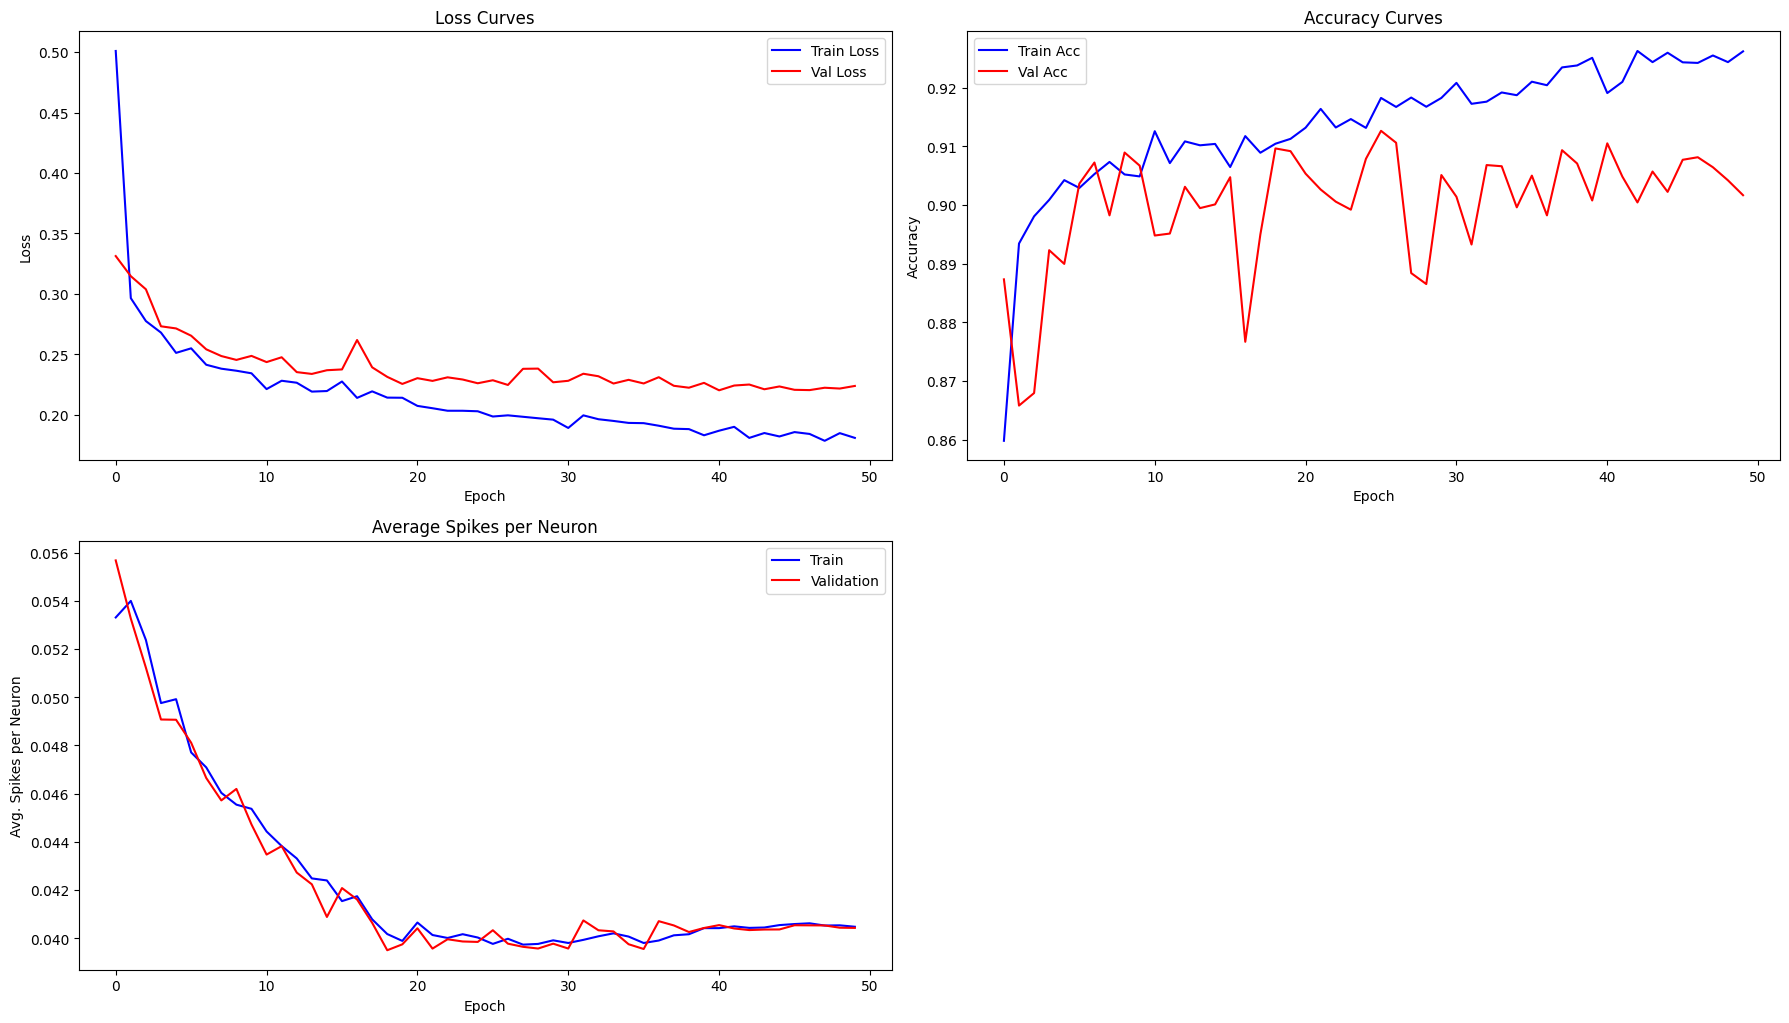

In [21]:
plot_training_results(history)

In [22]:
# sample 12000 data points from test data with equal distribution of benign and malicious samples
test_data_sample = test_df_encoded.groupby("Label").sample(2000, random_state=42)

test_dataset_sample = CustomDataset(test_data_sample, f"{DATASET_DIR}/images", transform=val_transform)
test_data_loader_sample = DataLoader(test_dataset_sample, batch_size=BATCH_SIZE, shuffle=False)

In [23]:
def test_model(model, test_dataloader, device="cuda"):
    with torch.no_grad():
        model.eval()
        correct = 0
        total = 0
        total_spikes = 0
        total_neurons = None
        all_preds = []
        all_labels = []
        
        for inputs, labels in tqdm(test_dataloader, desc=f'Testing'):
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            
            # Collect test spikes
            spikes_conv1 = torch.sum(model.spk1).item()
            spikes_conv2 = torch.sum(model.spk2).item()
            total_spikes += spikes_conv1 + spikes_conv2

            # Calculate number of spiking neurons
            if total_neurons is None:
                conv1_neurons = model.conv1.conv.out_channels * model.spk1.shape[2:].numel()
                conv2_neurons = model.conv2.conv.out_channels * model.spk2.shape[2:].numel()
                total_neurons = conv1_neurons + conv2_neurons

            predicted = torch.argmax(outputs.data, 1)
            total += labels.size(0)

            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

        accuracy = correct / total
        avg_spikes = total_spikes / (total_neurons * model.time_steps * len(test_dataloader.dataset))

        print(f'Test Accuracy: {accuracy:.4f} | Avg. Spikes per Neuron: {avg_spikes:.4f}')

    return accuracy, all_preds, all_labels

acc, y_pred, y_true = test_model(model, test_data_loader_sample, device=device)

Testing: 100%|██████████| 300/300 [00:13<00:00, 22.88it/s]

Test Accuracy: 0.9012 | Avg. Spikes per Neuron: 0.0405


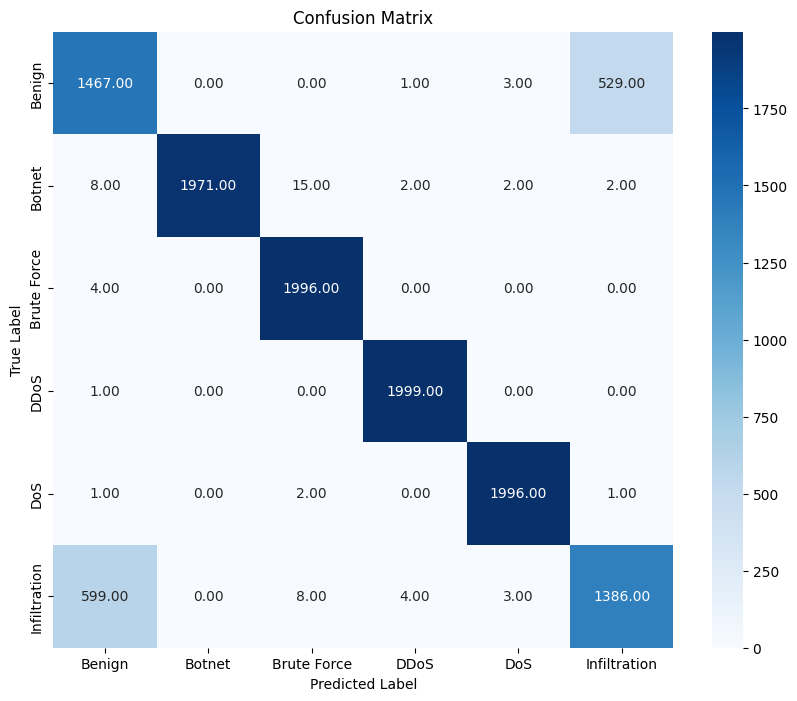

              precision    recall  f1-score   support

      Benign       0.71      0.73      0.72      2000
      Botnet       1.00      0.99      0.99      2000
 Brute Force       0.99      1.00      0.99      2000
        DDoS       1.00      1.00      1.00      2000
         DoS       1.00      1.00      1.00      2000
Infiltration       0.72      0.69      0.71      2000

    accuracy                           0.90     12000
   macro avg       0.90      0.90      0.90     12000
weighted avg       0.90      0.90      0.90     12000



In [24]:
def plot_cm(y_true, y_pred, classes, title='Confusion Matrix'):
    """Plot confusion matrix."""
    from sklearn.metrics import confusion_matrix, classification_report
    import seaborn as sns
    import matplotlib.pyplot as plt

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt=".2f", cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title(title)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()


    class_report = classification_report(y_true, y_pred, target_names=classes)
    print(class_report)

plot_cm(y_true, y_pred, LE.classes_, title='Confusion Matrix')